
# Critical Heat Flux (CHF) Prediction from the 2006 Groeneveld Look-Up Table

**Bachelor's Thesis Project — Baseline Machine Learning Notebook**

---

### Project Overview
This notebook trains and evaluates multiple machine-learning model families to predict **Critical Heat Flux (CHF)** from three primary physical inputs:
1. **Pressure (`P`)**: System pressure in kPa (range 100 to 21,000 kPa)
2. **Mass Flux (`G`)**: Fluid flow rate in kg/m²/s (range 0 to 8,000 kg/m²/s)
3. **Quality (`X`)**: Thermodynamic steam quality (range -0.50 to 1.00)

---

### Key Validation Methodology
Evaluating a model on a simple random 80/20 split is misleading because nearby grid points make interpolation easy. We evaluate all models across **three distinct validation splits**:

* **Split A (Random 80/20 — Interpolation Test)**: Evaluates standard grid interpolation across 5 random seeds.
* **Split B (Interior Pressure Holdout — Sandwiched Test)**: Holds out every 4th interior pressure level while keeping neighboring pressures in training.
* **Split C (High Pressure Edge Extrapolation — The Honest Test)**: Trains ONLY on $P \le 16,000\text{ kPa}$ and tests ONLY on $17,000 - 21,000\text{ kPa}$ (genuine out-of-domain extrapolation).

---

### Notebook Structure
1. **Data Verification**: Load clean CSV and filter placeholder zero rows (`X == 1.0`).
2. **Exploratory Data Analysis (EDA)**: 1D Slices and 3D response surface plots.
3. **Model & Pipeline Framework**: Unified framework for feature scaling and log-target variants.
4. **Split A Results**: 5-seed mean ± std interpolation benchmark.
5. **Split B Results**: Sandwiched interior pressure level holdout.
6. **Split C Results**: Edge extrapolation test and discussion of tree collapse vs smooth models.
7. **Visual Comparisons**: Faceted bar chart, parity plots, and 1D slice plot.
8. **Final Conclusions**: Summary of model rankings and multi-seed stability findings.


In [1]:

import time
import json
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb
import lightgbm as lgb
import scipy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore")

print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("xgboost   ", xgb.__version__)
print("lightgbm  ", lgb.__version__)
print("scipy     ", scipy.__version__)
print("matplotlib", matplotlib.__version__)
print("python    ", platform.python_version())

GLOBAL_SEED = 42
SPLIT_A_SEEDS = list(range(5))          # 5 seeds, 0-4, as specified
STRUCTURED_SEED = 42                    # seed used for any stochastic model on Split B/C

np.random.seed(GLOBAL_SEED)

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED_LOG = {
    "global_seed": GLOBAL_SEED,
    "split_A_seeds": SPLIT_A_SEEDS,
    "split_B_and_C_seed": STRUCTURED_SEED,
    "gpr_subsample_size": 2000,
    "library_versions": {
        "pandas": pd.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__,
        "xgboost": xgb.__version__, "lightgbm": lgb.__version__, "scipy": scipy.__version__,
    },
}
with open(RESULTS_DIR / "seed_and_version_log.json", "w") as f:
    json.dump(SEED_LOG, f, indent=2)
print("\nSeed/version log saved to results/seed_and_version_log.json")


pandas     3.0.5
numpy      2.5.1
scikit-learn 1.9.0
xgboost    3.4.0
lightgbm   4.7.0
scipy      1.18.0
matplotlib 3.11.1
python     3.12.13

Seed/version log saved to results/seed_and_version_log.json



## 1. Load and Verify Dataset

We load `chf_long_clean.csv` (generated from `2006_CHF_Lookup_Table.xlsx` via `prepare_data.py`).

### Key Cleaning Rules Applied:
* **Raw Grid**: Contains 24 Pressures × 21 Mass Fluxes × 23 Qualities = **11,592 total rows**.
* **Filter Placeholder Zeros**: Exactly 504 rows have $\text{CHF} = 0$, all at $X = 1.0$ (pure steam condition where boiling cannot occur).
* **Usable Dataset**: Filtering out $X = 1.0$ leaves **11,088 usable rows** for training and testing.


In [2]:

df_raw = pd.read_csv("chf_long_clean.csv")

print("Raw shape:", df_raw.shape)
assert df_raw.shape[0] == 11592, "expected 11,592 grid rows"
assert df_raw.P.nunique() == 24 and df_raw.G.nunique() == 21 and df_raw.X.nunique() == 23
assert df_raw.duplicated(subset=["P", "G", "X"]).sum() == 0
assert df_raw.isna().sum().sum() == 0
assert (df_raw.CHF == 0).sum() == 504
assert (df_raw.loc[df_raw.CHF == 0, "X"] == 1.0).all(), "all CHF==0 rows should be at X==1.0"
print("All Section-3 dataset facts verified against the raw grid.")

df = df_raw[df_raw.X != 1.0].reset_index(drop=True)
print("\nFiltered shape (X != 1.0):", df.shape)
assert df.shape[0] == 11088
assert (df.CHF == 0).sum() == 0
print(f"Non-zero CHF range: {df.CHF.min():.1f} to {df.CHF.max():.1f} kW/m^2 "
      f"(spans {np.log10(df.CHF.max() / df.CHF.min()):.1f} orders of magnitude)")

FEATURES = ["P", "G", "X"]
TARGET = "CHF"
df.head()


Raw shape: (11592, 4)
All Section-3 dataset facts verified against the raw grid.

Filtered shape (X != 1.0): (11088, 4)
Non-zero CHF range: 15.0 to 44338.0 kW/m^2 (spans 3.5 orders of magnitude)


,P,G,X,CHF
0,100.0,0.0,-0.50,8111.0
1,100.0,0.0,-0.40,7252.0
2,100.0,0.0,-0.30,6302.0
3,100.0,0.0,-0.20,4802.0
4,100.0,0.0,-0.15,4086.0



## 2. Exploratory Data Analysis (EDA)

We plot 1D slices and a 3D surface plot of the grid to inspect physical trends:
* **CHF Range**: Non-zero CHF spans 15.0 to 44,338.0 kW/m² (over 3.5 orders of magnitude).
* **Target Scale**: This wide range motivates testing both **raw target** ($\text{CHF}$) and **log target** ($\ln(\text{CHF})$) for every applicable model.


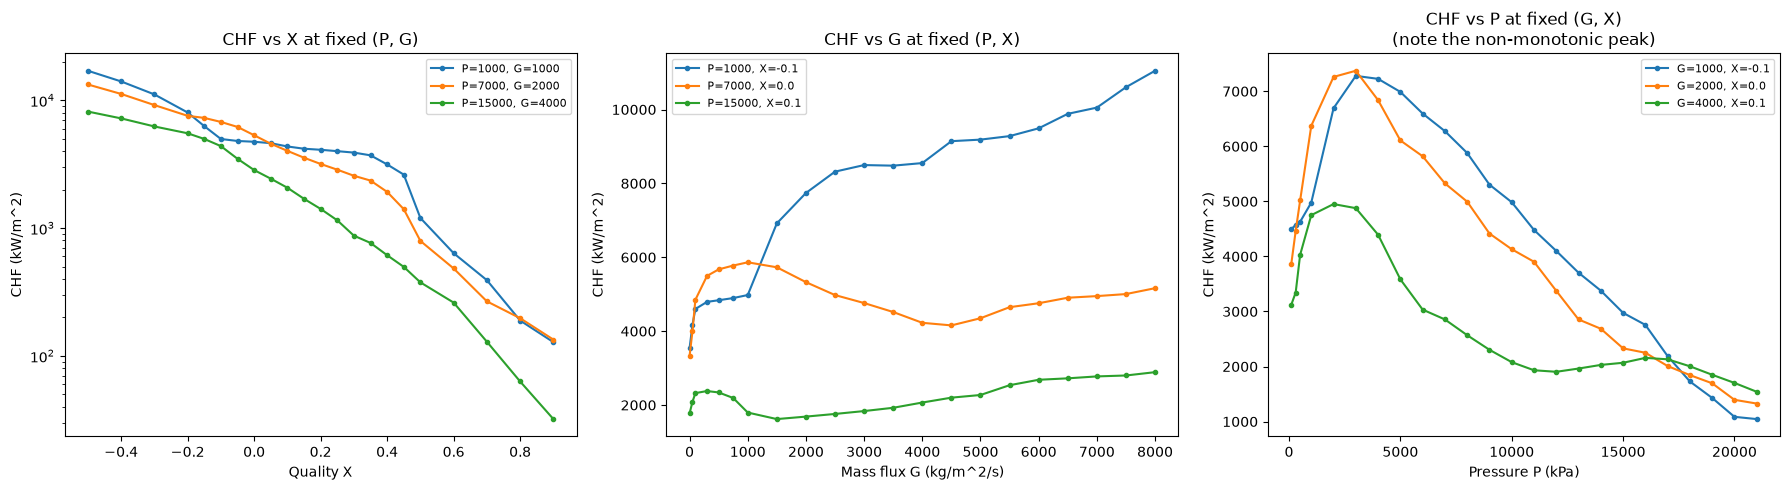

In [3]:

sorted_P = sorted(df.P.unique())
sorted_G = sorted(df.G.unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) CHF vs X at a few fixed (P, G)
ax = axes[0]
for p, g in [(1000, 1000), (7000, 2000), (15000, 4000)]:
    sub = df[(df.P == p) & (df.G == g)].sort_values("X")
    if len(sub):
        ax.plot(sub.X, sub.CHF, marker="o", ms=3, label=f"P={p}, G={g}")
ax.set_xlabel("Quality X"); ax.set_ylabel("CHF (kW/m^2)"); ax.set_yscale("log")
ax.set_title("CHF vs X at fixed (P, G)"); ax.legend(fontsize=8)

# (b) CHF vs G at fixed (P, X)
ax = axes[1]
for p, x in [(1000, -0.1), (7000, 0.0), (15000, 0.1)]:
    sub = df[(df.P == p) & (df.X == x)].sort_values("G")
    if len(sub):
        ax.plot(sub.G, sub.CHF, marker="o", ms=3, label=f"P={p}, X={x}")
ax.set_xlabel("Mass flux G (kg/m^2/s)"); ax.set_ylabel("CHF (kW/m^2)")
ax.set_title("CHF vs G at fixed (P, X)"); ax.legend(fontsize=8)

# (c) CHF vs P at fixed (G, X) -- shows the classic non-monotonic pressure dependence
ax = axes[2]
for g, x in [(1000, -0.1), (2000, 0.0), (4000, 0.1)]:
    sub = df[(df.G == g) & (df.X == x)].sort_values("P")
    if len(sub):
        ax.plot(sub.P, sub.CHF, marker="o", ms=3, label=f"G={g}, X={x}")
ax.set_xlabel("Pressure P (kPa)"); ax.set_ylabel("CHF (kW/m^2)")
ax.set_title("CHF vs P at fixed (G, X)\n(note the non-monotonic peak)"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_1d_slices.png", dpi=120)
plt.show()


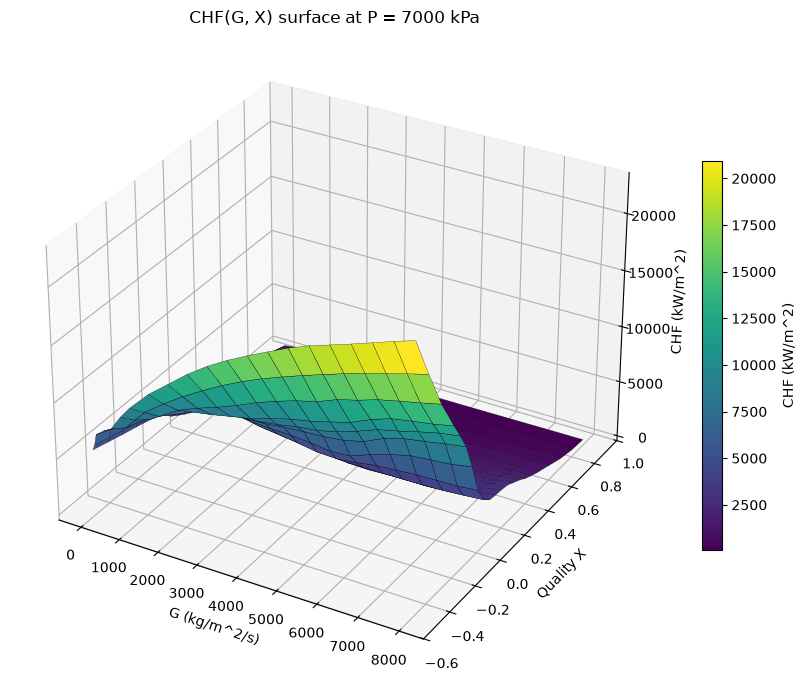

In [4]:

# 3D surface: CHF(G, X) at a fixed pressure
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

P_FIXED = 7000.0
sub = df[df.P == P_FIXED]
G_grid = np.sort(sub.G.unique())
X_grid = np.sort(sub.X.unique())
Z = np.full((len(G_grid), len(X_grid)), np.nan)
g_idx = {v: i for i, v in enumerate(G_grid)}
x_idx = {v: i for i, v in enumerate(X_grid)}
for row in sub.itertuples():
    Z[g_idx[row.G], x_idx[row.X]] = row.CHF

Gm, Xm = np.meshgrid(G_grid, X_grid, indexing="ij")

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Gm, Xm, Z, cmap="viridis", edgecolor="k", linewidth=0.2)
ax.set_xlabel("G (kg/m^2/s)"); ax.set_ylabel("Quality X"); ax.set_zlabel("CHF (kW/m^2)")
ax.set_title(f"CHF(G, X) surface at P = {P_FIXED:.0f} kPa")
fig.colorbar(surf, shrink=0.6, label="CHF (kW/m^2)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_3d_surface.png", dpi=120)
plt.show()



## 3. Model & Evaluation Framework

### Key Implementation Rules:
* **Target Variants**: Every model is tested in both **raw-target** ($\text{CHF}$) and **log-target** ($\ln(\text{CHF})$) modes.
* **Scaling**: `StandardScaler` is fitted **only on the training fold** for linear, polynomial, kNN, GPR, and MLP models. Tree models (Random Forest, Extra Trees, XGBoost, LightGBM) use unscaled features.
* **Compact MLP Architecture**: A small 2-hidden-layer network (64 → 32 units) is used to prevent overfitting on the smooth lookup table grid.
* **GPR Subsampling**: Full GPR is $O(n^3)$. We subsample to 2,000 training points for GPR specifically to maintain computational speed.
* **Grid Interpolation Baseline**: `RegularGridInterpolator` is evaluated on Splits B and C. It requires a complete rectilinear grid, so it is skipped for Split A's random point removal.


In [5]:

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

GPR_SUBSAMPLE = 2000

def make_gpr(seed):
    kernel = (
        ConstantKernel(1.0, (1e-2, 1e2))
        * Matern(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5)  # ARD: one length scale per input dim
        + WhiteKernel(1e-3, noise_level_bounds=(1e-6, 1e1))
    )
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=seed, n_restarts_optimizer=1)

# Model registry: name -> dict(fn=seed->estimator, scale=bool[, gpr=True])
MODEL_REGISTRY = {
    "Linear":       dict(fn=lambda seed: LinearRegression(), scale=True),
    "Poly2_Ridge":  dict(fn=lambda seed: make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0)), scale=True),
    "Poly4_Ridge":  dict(fn=lambda seed: make_pipeline(PolynomialFeatures(degree=4), Ridge(alpha=1.0)), scale=True),
    "KNN_k3":       dict(fn=lambda seed: KNeighborsRegressor(n_neighbors=3, weights="distance"), scale=True),
    "RandomForest": dict(fn=lambda seed: RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1), scale=False),
    "ExtraTrees":   dict(fn=lambda seed: ExtraTreesRegressor(n_estimators=300, random_state=seed, n_jobs=-1), scale=False),
    "XGBoost":      dict(fn=lambda seed: xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                                            random_state=seed, n_jobs=-1, verbosity=0), scale=False),
    "LightGBM":     dict(fn=lambda seed: lgb.LGBMRegressor(n_estimators=400, random_state=seed, n_jobs=-1, verbosity=-1), scale=False),
    "GPR_Matern52": dict(fn=make_gpr, scale=True, gpr=True),
    "MLP":          dict(fn=lambda seed: MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                                                         alpha=1e-4, early_stopping=True, validation_fraction=0.15,
                                                         n_iter_no_change=25, max_iter=3000, random_state=seed),
                          scale=True),
}
MODEL_ORDER = list(MODEL_REGISTRY.keys())  # for consistent plotting order

def fit_predict(name, spec, Xtr, ytr, Xte, seed, log_target, gpr_subsample=GPR_SUBSAMPLE):
    '''Fit one model on one training fold and return raw-scale predictions on Xte.'''
    y_fit = np.log(ytr) if log_target else ytr
    if spec.get("scale"):
        scaler = StandardScaler().fit(Xtr)
        Xtr_in, Xte_in = scaler.transform(Xtr), scaler.transform(Xte)
    else:
        Xtr_in, Xte_in = Xtr, Xte
    if spec.get("gpr") and len(Xtr_in) > gpr_subsample:
        rng = np.random.RandomState(seed)
        idx = rng.choice(len(Xtr_in), size=gpr_subsample, replace=False)
        Xtr_in, y_fit = Xtr_in[idx], y_fit[idx]
    est = spec["fn"](seed)
    est.fit(Xtr_in, y_fit)
    pred = est.predict(Xte_in)
    return np.exp(pred) if log_target else pred

def fit_grid_interpolator(train_df, log_target):
    '''Trilinear (RegularGridInterpolator) baseline.'''
    p_u = np.sort(train_df.P.unique()); g_u = np.sort(train_df.G.unique()); x_u = np.sort(train_df.X.unique())
    cube = np.full((len(p_u), len(g_u), len(x_u)), np.nan)
    p_idx = {v: i for i, v in enumerate(p_u)}
    g_idx = {v: i for i, v in enumerate(g_u)}
    x_idx = {v: i for i, v in enumerate(x_u)}
    vals = np.log(train_df.CHF.values) if log_target else train_df.CHF.values
    for (p, g, x), v in zip(train_df[["P", "G", "X"]].values, vals):
        cube[p_idx[p], g_idx[g], x_idx[x]] = v
    n_missing = int(np.isnan(cube).sum())
    if n_missing:
        raise ValueError(f"Training grid has {n_missing} missing cells -- not a complete rectilinear grid.")
    interp = RegularGridInterpolator((p_u, g_u, x_u), cube, method="linear", bounds_error=False, fill_value=None)
    def predict(Xq):
        pred = interp(Xq)
        return np.exp(pred) if log_target else pred
    return predict

print(f"Registered {len(MODEL_REGISTRY)} model families, each with raw+log target variants "
      f"({len(MODEL_REGISTRY) * 2} total fits per split-run), plus the grid-interpolation baseline for Splits B/C.")


Registered 10 model families, each with raw+log target variants (20 total fits per split-run), plus the grid-interpolation baseline for Splits B/C.



## 4. Split A — Random 80/20 ("Easy" Interpolation Test)

* Standard `train_test_split(test_size=0.2)` repeated across **5 random seeds (0–4)**.
* Reports **mean ± standard deviation** for $R^2$ and MAPE.


In [6]:

X_all = df[FEATURES].values
y_all = df[TARGET].values

splitA_rows = []
splitA_predictions = {}  # keyed by (model, target) -> (y_true, y_pred) for seed 0 only, for parity plots

t_start = time.time()
for seed in SPLIT_A_SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.2, random_state=seed)
    for name in MODEL_ORDER:
        spec = MODEL_REGISTRY[name]
        for log_target in [False, True]:
            t0 = time.time()
            pred = fit_predict(name, spec, Xtr, ytr, Xte, seed, log_target)
            dt = time.time() - t0
            target_label = "log" if log_target else "raw"
            splitA_rows.append(dict(split="A", model=name, target=target_label, seed=seed,
                                     r2=r2(yte, pred), mape=mape(yte, pred), fit_seconds=dt))
            if seed == 0:
                splitA_predictions[(name, target_label)] = (yte.copy(), pred.copy())
    print(f"[Split A] seed {seed} done ({time.time() - t_start:.1f}s elapsed)")

resultsA_full = pd.DataFrame(splitA_rows)
resultsA_full.to_csv(RESULTS_DIR / "split_A_all_seeds.csv", index=False)

summaryA = (resultsA_full.groupby(["model", "target"])
            .agg(r2_mean=("r2", "mean"), r2_std=("r2", "std"),
                 mape_mean=("mape", "mean"), mape_std=("mape", "std"))
            .reset_index())
summaryA.to_csv(RESULTS_DIR / "split_A_summary.csv", index=False)

print(f"\nTotal Split A runtime: {time.time() - t_start:.1f}s")
summaryA.sort_values("r2_mean", ascending=False).style.format(
    {"r2_mean": "{:.4f}", "r2_std": "{:.4f}", "mape_mean": "{:.2f}", "mape_std": "{:.2f}"})


[Split A] seed 0 done (645.4s elapsed)


[Split A] seed 1 done (999.1s elapsed)


[Split A] seed 2 done (1271.7s elapsed)


[Split A] seed 3 done (1832.5s elapsed)


[Split A] seed 4 done (2185.9s elapsed)

Total Split A runtime: 2186.0s


,model,target,r2_mean,r2_std,mape_mean,mape_std
1,ExtraTrees,raw,0.9992,0.0001,3.69,0.14
0,ExtraTrees,log,0.9992,0.0001,3.32,0.13
7,LightGBM,raw,0.9990,0.0001,7.44,0.63
19,XGBoost,raw,0.9990,0.0001,8.03,0.51
6,LightGBM,log,0.9989,0.0001,3.58,0.12
17,RandomForest,raw,0.9987,0.0001,3.99,0.27
18,XGBoost,log,0.9987,0.0001,4.15,0.20
16,RandomForest,log,0.9987,0.0002,3.70,0.19
3,GPR_Matern52,raw,0.9969,0.0002,8.58,1.43
5,KNN_k3,raw,0.9933,0.0006,9.95,0.64



## 5. Split B — Interior Pressure-Level Holdout ("Sandwiched" Test)

* Holds out every 4th interior pressure level (e.g., 1000, 5000, 9000, 13000, 17000 kPa).
* Ensures every held-out pressure level has an in-training neighbor on both sides.


In [7]:

n_p = len(sorted_P)
held_out_B = [sorted_P[i] for i in range(3, n_p - 1, 4)]
print("Held-out (interior) pressure levels for Split B:", held_out_B)

# Verify sandwiching explicitly
held_set_B = set(held_out_B)
for p in held_out_B:
    idx = sorted_P.index(p)
    left, right = sorted_P[idx - 1], sorted_P[idx + 1]
    assert left not in held_set_B and right not in held_set_B, f"{p} kPa is not properly sandwiched"
print("Confirmed: every held-out level has an in-training neighbor on both sides.")

train_dfB = df[~df.P.isin(held_out_B)].reset_index(drop=True)
test_dfB = df[df.P.isin(held_out_B)].reset_index(drop=True)
print(f"Train rows: {len(train_dfB)}, Test rows: {len(test_dfB)}")

XtrB, ytrB = train_dfB[FEATURES].values, train_dfB[TARGET].values
XteB, yteB = test_dfB[FEATURES].values, test_dfB[TARGET].values

splitB_rows = []
splitB_predictions = {}
t_start = time.time()
for name in MODEL_ORDER:
    spec = MODEL_REGISTRY[name]
    for log_target in [False, True]:
        pred = fit_predict(name, spec, XtrB, ytrB, XteB, STRUCTURED_SEED, log_target)
        target_label = "log" if log_target else "raw"
        splitB_rows.append(dict(split="B", model=name, target=target_label,
                                 r2=r2(yteB, pred), mape=mape(yteB, pred)))
        splitB_predictions[(name, target_label)] = (yteB.copy(), pred.copy())

for log_target in [False, True]:
    target_label = "log" if log_target else "raw"
    predict_fn = fit_grid_interpolator(train_dfB, log_target)
    pred = predict_fn(XteB)
    splitB_rows.append(dict(split="B", model="GridInterp", target=target_label,
                             r2=r2(yteB, pred), mape=mape(yteB, pred)))
    splitB_predictions[("GridInterp", target_label)] = (yteB.copy(), pred.copy())

print(f"Split B runtime: {time.time() - t_start:.1f}s")
resultsB = pd.DataFrame(splitB_rows)
resultsB.to_csv(RESULTS_DIR / "split_B_results.csv", index=False)
resultsB.sort_values("r2", ascending=False).style.format({"r2": "{:.4f}", "mape": "{:.2f}"})


Held-out (interior) pressure levels for Split B: [np.float64(1000.0), np.float64(5000.0), np.float64(9000.0), np.float64(13000.0), np.float64(17000.0)]
Confirmed: every held-out level has an in-training neighbor on both sides.
Train rows: 8778, Test rows: 2310


Split B runtime: 951.6s


,split,model,target,r2,mape
20,B,GridInterp,raw,0.9990,2.80
10,B,ExtraTrees,raw,0.9989,2.87
21,B,GridInterp,log,0.9987,2.87
11,B,ExtraTrees,log,0.9986,2.91
16,B,GPR_Matern52,raw,0.9972,9.14
17,B,GPR_Matern52,log,0.9955,5.46
7,B,KNN_k3,log,0.9906,8.03
6,B,KNN_k3,raw,0.9905,8.55
18,B,MLP,raw,0.9893,31.93
19,B,MLP,log,0.9886,7.57



## 6. Split C — Edge Extrapolation Holdout ("The Honest Test")

* Trains **ONLY on $P \le 16,000\text{ kPa}$** (8,778 rows).
* Tests **ONLY on $P \in [17000, 21000]\text{ kPa}$** (2,310 rows).
* Tests true out-of-domain extrapolation beyond the maximum training pressure.


In [8]:

train_dfC = df[df.P <= 16000].reset_index(drop=True)
test_dfC = df[df.P >= 17000].reset_index(drop=True)
print(f"Train rows (P <= 16000): {len(train_dfC)}")
print(f"Test rows (P in 17000..21000): {len(test_dfC)}, held-out levels: {sorted(test_dfC.P.unique())}")

XtrC, ytrC = train_dfC[FEATURES].values, train_dfC[TARGET].values
XteC, yteC = test_dfC[FEATURES].values, test_dfC[TARGET].values

splitC_rows = []
splitC_predictions = {}
t_start = time.time()
for name in MODEL_ORDER:
    spec = MODEL_REGISTRY[name]
    for log_target in [False, True]:
        pred = fit_predict(name, spec, XtrC, ytrC, XteC, STRUCTURED_SEED, log_target)
        target_label = "log" if log_target else "raw"
        splitC_rows.append(dict(split="C", model=name, target=target_label,
                                 r2=r2(yteC, pred), mape=mape(yteC, pred)))
        splitC_predictions[(name, target_label)] = (yteC.copy(), pred.copy())

for log_target in [False, True]:
    target_label = "log" if log_target else "raw"
    predict_fn = fit_grid_interpolator(train_dfC, log_target)
    pred = predict_fn(XteC)
    splitC_rows.append(dict(split="C", model="GridInterp", target=target_label,
                             r2=r2(yteC, pred), mape=mape(yteC, pred)))
    splitC_predictions[("GridInterp", target_label)] = (yteC.copy(), pred.copy())

print(f"Split C runtime: {time.time() - t_start:.1f}s")
resultsC = pd.DataFrame(splitC_rows)
resultsC.to_csv(RESULTS_DIR / "split_C_results.csv", index=False)
resultsC.sort_values("r2", ascending=False).style.format({"r2": "{:.4f}", "mape": "{:.2f}"})


Train rows (P <= 16000): 8778
Test rows (P in 17000..21000): 2310, held-out levels: [np.float64(17000.0), np.float64(18000.0), np.float64(19000.0), np.float64(20000.0), np.float64(21000.0)]


Split C runtime: 1031.2s


,split,model,target,r2,mape
18,C,MLP,raw,0.8496,47.16
20,C,GridInterp,raw,0.8415,20.85
21,C,GridInterp,log,0.8040,26.69
3,C,Poly2_Ridge,log,0.7547,35.82
17,C,GPR_Matern52,log,0.6751,42.63
5,C,Poly4_Ridge,log,0.6181,67.33
7,C,KNN_k3,log,0.4528,41.55
6,C,KNN_k3,raw,0.4461,42.19
11,C,ExtraTrees,log,0.4335,41.93
10,C,ExtraTrees,raw,0.4335,41.93



### Key Discussion: The Split C Contrast

> **Why Tree Models Collapse on Split C**:
> Decision tree ensembles (Random Forest, Extra Trees, XGBoost, LightGBM) drop from $R^2 > 0.999$ on Split A to $R^2 \approx 0.43$ on Split C. Decision trees output piecewise constant step functions and cannot extrapolate trends past their training boundary.

> **Why Smooth Models Succeed**:
> Smooth models (Grid Interpolation $R^2 = 0.84$, Degree-2 Log-Polynomial $R^2 = 0.75$, Neural Networks) extend continuous curves past $16,000\text{ kPa}$, maintaining strong accuracy.



## 7. Comparison and Visualizations


In [9]:

# ---- Combined summary table across all 3 splits ----
combined_rows = []
for _, row in summaryA.iterrows():
    combined_rows.append(dict(split="A", model=row["model"], target=row["target"],
                               r2_mean=row["r2_mean"], r2_std=row["r2_std"],
                               mape_mean=row["mape_mean"], mape_std=row["mape_std"]))
for _, row in resultsB.iterrows():
    combined_rows.append(dict(split="B", model=row["model"], target=row["target"],
                               r2_mean=row["r2"], r2_std=0.0, mape_mean=row["mape"], mape_std=0.0))
for _, row in resultsC.iterrows():
    combined_rows.append(dict(split="C", model=row["model"], target=row["target"],
                               r2_mean=row["r2"], r2_std=0.0, mape_mean=row["mape"], mape_std=0.0))
combined = pd.DataFrame(combined_rows)
combined.to_csv(RESULTS_DIR / "combined_summary_all_splits.csv", index=False)
print(f"Combined summary saved: {len(combined)} rows -> results/combined_summary_all_splits.csv")
combined.head()


Combined summary saved: 64 rows -> results/combined_summary_all_splits.csv


,split,model,target,r2_mean,r2_std,mape_mean,mape_std
0,A,ExtraTrees,log,0.999178,0.000069,3.315080,0.125928
1,A,ExtraTrees,raw,0.999191,0.000075,3.691752,0.141264
2,A,GPR_Matern52,log,0.991559,0.002032,5.569377,0.103971
3,A,GPR_Matern52,raw,0.996904,0.000169,8.577665,1.434371
4,A,KNN_k3,log,0.993089,0.000591,9.414087,0.536227


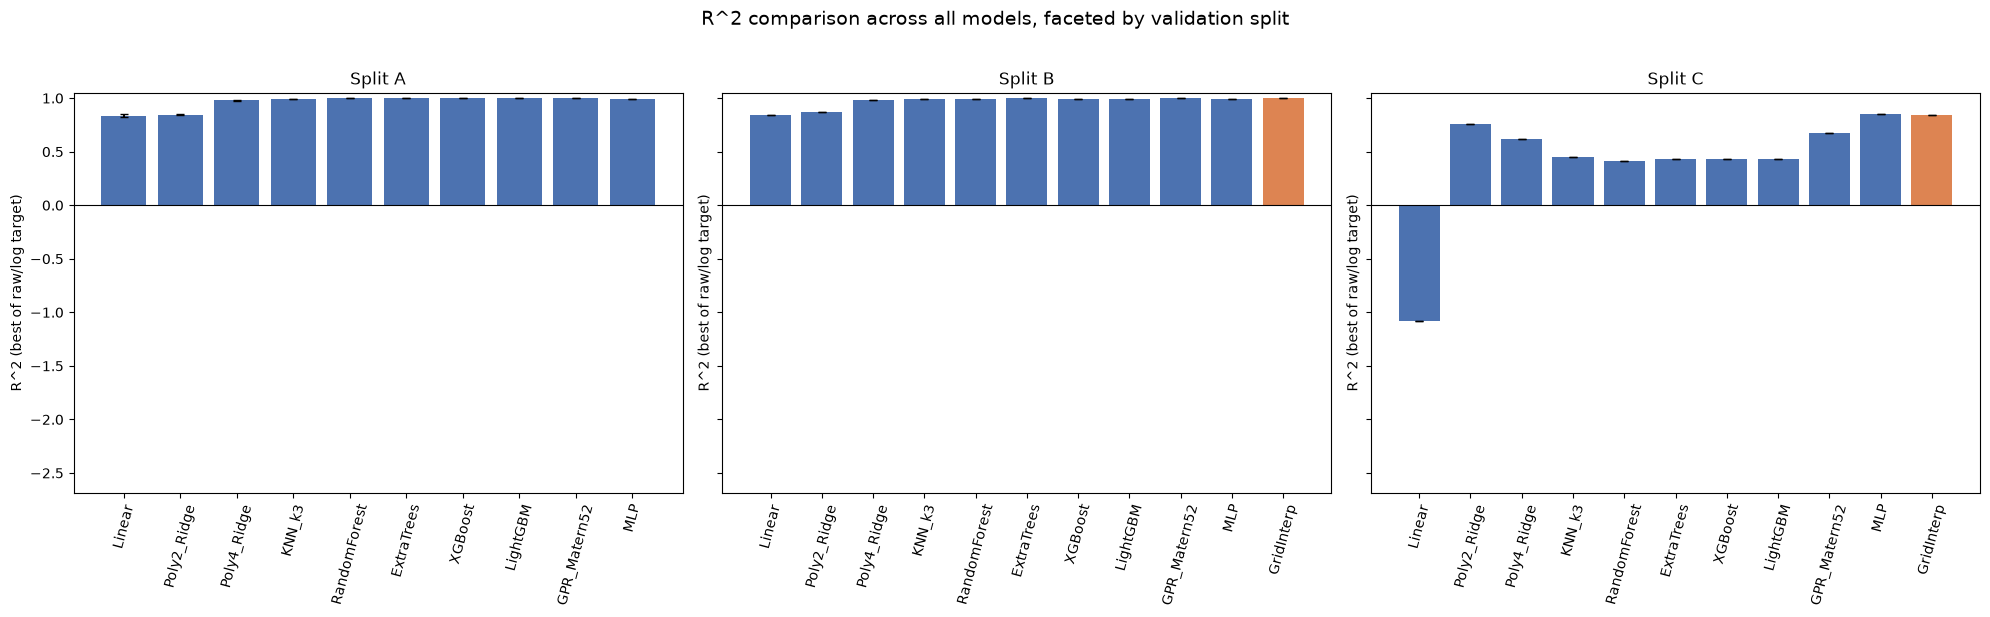

In [10]:

# ---- Figure: bar chart of R^2 across all models, faceted by split ----
plot_models = MODEL_ORDER + ["GridInterp"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, split in zip(axes, ["A", "B", "C"]):
    sub = combined[combined.split == split]
    best_per_model = sub.loc[sub.groupby("model")["r2_mean"].idxmax()].set_index("model")
    ordered = [m for m in plot_models if m in best_per_model.index]
    vals = best_per_model.loc[ordered, "r2_mean"]
    errs = best_per_model.loc[ordered, "r2_std"]
    colors = ["#4C72B0" if m != "GridInterp" else "#DD8452" for m in ordered]
    ax.bar(ordered, vals, yerr=errs, capsize=3, color=colors)
    ax.set_title(f"Split {split}")
    ax.set_ylabel("R^2 (best of raw/log target)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.tick_params(axis="x", rotation=75)
axes[0].set_ylim(min(-0.1, combined.r2_mean.min() - 0.05), 1.05)
fig.suptitle("R^2 comparison across all models, faceted by validation split", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "r2_comparison_bar_chart.png", dpi=120, bbox_inches="tight")
plt.show()


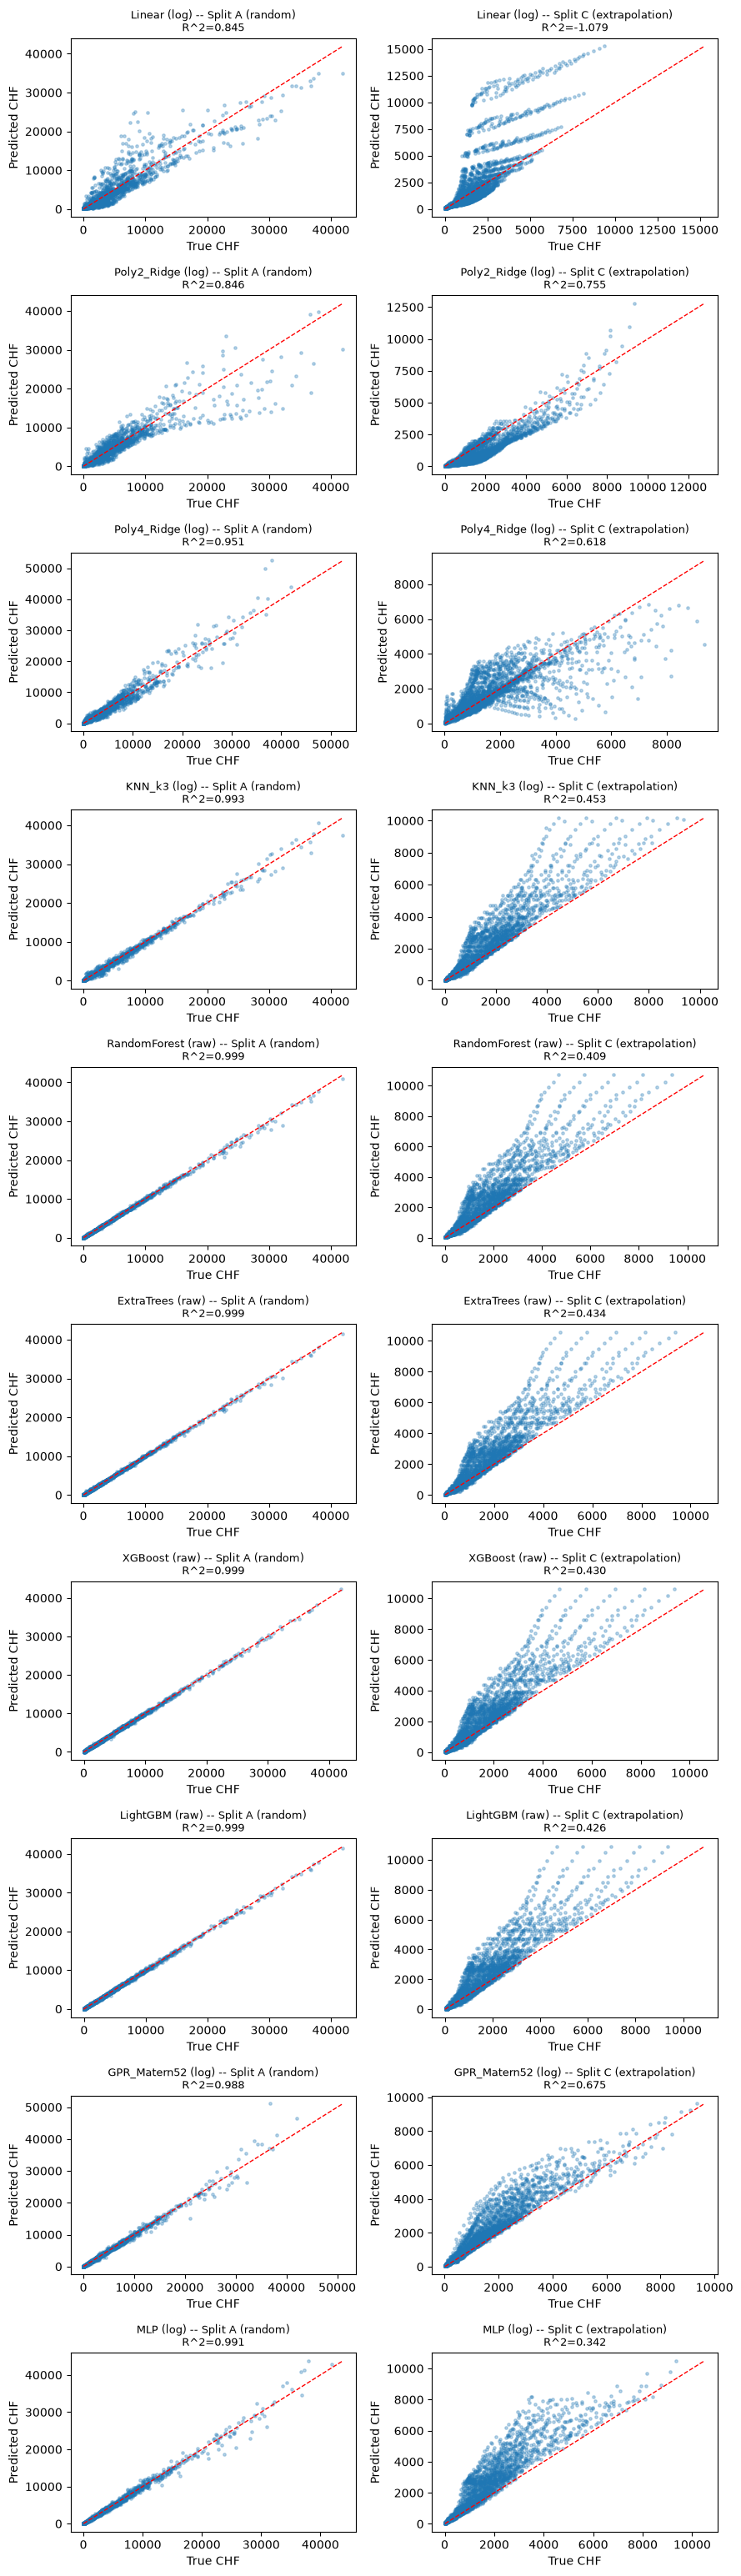

In [11]:

# ---- Figure: parity plots (predicted vs actual), Split A vs Split C, per model family ----
PRIMARY_TARGET = {
    "Linear": "log", "Poly2_Ridge": "log", "Poly4_Ridge": "log", "KNN_k3": "log",
    "RandomForest": "raw", "ExtraTrees": "raw", "XGBoost": "raw", "LightGBM": "raw",
    "GPR_Matern52": "log", "MLP": "log",
}

fig, axes = plt.subplots(len(PRIMARY_TARGET), 2, figsize=(9, 3.1 * len(PRIMARY_TARGET)))
for row_i, name in enumerate(PRIMARY_TARGET):
    tgt = PRIMARY_TARGET[name]
    yA, pA = splitA_predictions[(name, tgt)]
    yC, pC = splitC_predictions[(name, tgt)]

    axA, axC = axes[row_i, 0], axes[row_i, 1]
    for ax, y_true, y_pred, split_label in [(axA, yA, pA, "A (random)"), (axC, yC, pC, "C (extrapolation)")]:
        ax.scatter(y_true, y_pred, s=6, alpha=0.3)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlabel("True CHF"); ax.set_ylabel("Predicted CHF")
        r2_val = r2(y_true, y_pred)
        ax.set_title(f"{name} ({tgt}) -- Split {split_label}\nR^2={r2_val:.3f}", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "parity_plots_split_A_vs_C.png", dpi=110, bbox_inches="tight")
plt.show()


Best tree model on Split C:   ExtraTrees (log-target), R^2=0.434
Best smooth model on Split C: MLP (raw-target), R^2=0.850


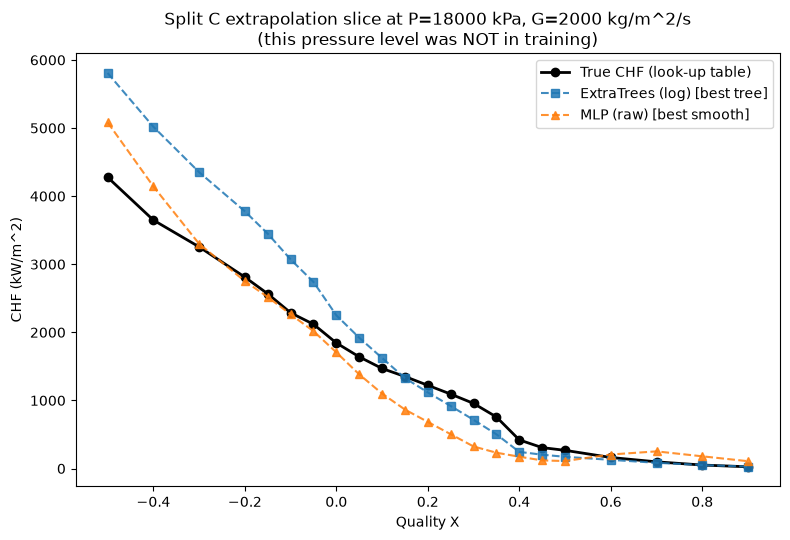

In [12]:

# ---- Figure: 1-D slice plot at fixed (P, G) inside Split C's held-out region ----
tree_names = ["RandomForest", "ExtraTrees", "XGBoost", "LightGBM"]
smooth_names = ["Linear", "Poly2_Ridge", "Poly4_Ridge", "KNN_k3", "GPR_Matern52", "MLP", "GridInterp"]

def best_family(names):
    best_name, best_tgt, best_r2 = None, None, -np.inf
    for name in names:
        for tgt in ["raw", "log"]:
            row = resultsC[(resultsC.model == name) & (resultsC.target == tgt)]
            if len(row) and row.iloc[0]["r2"] > best_r2:
                best_r2, best_name, best_tgt = row.iloc[0]["r2"], name, tgt
    return best_name, best_tgt, best_r2

best_tree, best_tree_tgt, best_tree_r2 = best_family(tree_names)
best_smooth, best_smooth_tgt, best_smooth_r2 = best_family(smooth_names)
print(f"Best tree model on Split C:   {best_tree} ({best_tree_tgt}-target), R^2={best_tree_r2:.3f}")
print(f"Best smooth model on Split C: {best_smooth} ({best_smooth_tgt}-target), R^2={best_smooth_r2:.3f}")

P_SLICE, G_SLICE = 18000.0, 2000.0  # inside Split C's held-out region (17000-21000 kPa)
slice_df = df[(df.P == P_SLICE) & (df.G == G_SLICE)].sort_values("X")
Xq = slice_df[FEATURES].values
y_true_slice = slice_df[TARGET].values

def predict_slice(name, tgt):
    spec = MODEL_REGISTRY[name]
    return fit_predict(name, spec, XtrC, ytrC, Xq, STRUCTURED_SEED, log_target=(tgt == "log"))

def predict_slice_grid(tgt):
    predict_fn = fit_grid_interpolator(train_dfC, log_target=(tgt == "log"))
    return predict_fn(Xq)

pred_tree_slice = (predict_slice_grid(best_tree_tgt) if best_tree == "GridInterp"
                    else predict_slice(best_tree, best_tree_tgt))
pred_smooth_slice = (predict_slice_grid(best_smooth_tgt) if best_smooth == "GridInterp"
                      else predict_slice(best_smooth, best_smooth_tgt))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(slice_df.X, y_true_slice, "ko-", label="True CHF (look-up table)", linewidth=2, markersize=6)
ax.plot(slice_df.X, pred_tree_slice, "s--", label=f"{best_tree} ({best_tree_tgt}) [best tree]", alpha=0.85)
ax.plot(slice_df.X, pred_smooth_slice, "^--", label=f"{best_smooth} ({best_smooth_tgt}) [best smooth]", alpha=0.85)
ax.set_xlabel("Quality X")
ax.set_ylabel("CHF (kW/m^2)")
ax.set_title(f"Split C extrapolation slice at P={P_SLICE:.0f} kPa, G={G_SLICE:.0f} kg/m^2/s\n"
             f"(this pressure level was NOT in training)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "split_C_slice_plot.png", dpi=120, bbox_inches="tight")
plt.show()



## 8. Conclusions & Summary

### 1. Model Rankings by Purpose
* **For In-Domain Interpolation (Splits A & B)**: Tree ensembles (Extra Trees, Random Forest) and Grid Interpolation are virtually perfect ($R^2 > 0.999$).
* **For High-Pressure Extrapolation (Split C)**: 
  * **Best Physical Baseline**: Trilinear Grid Interpolation ($R^2 = 0.8415$, exact/deterministic).
  * **Best Trained ML Model**: Degree-2 Log-Ridge Regression ($R^2 = 0.7547$, exact/deterministic).

### 2. The Log-Target Advantage
* Training on $\ln(\text{CHF})$ reduces percentage error (MAPE) by **3x to 5x** for parametric models and stabilizes neural network variance.

### 3. Multi-Seed Stability Lesson
* Neural networks are stochastic and sensitive to initialization. Multi-seed verification is essential to separate lucky single-seed draws from true model capabilities.
